# Lab 6: Logistic Regression & KNN Classification

**Name:** Abdul Sami

**Student ID:** 023-24-0211

**Section:** G

**GitHub Profile:** https://github.com/abdulsami911/Machine_learning_Practical

**Dataset:** Telco Customer Churn (cleaned in Lab 2, modeled in Lab 3, extended in Lab 4)

**Dataset Source:** Kaggle — Telco Customer Churn

> This notebook builds directly on `clean_churn.csv` from Lab 2 and reuses the exact benchmarks selected in Lab 3
> (Decision Tree, `max_depth=4`, gini) and Lab 4 (tuned Random Forest, `n_estimators=200, max_depth=None,
> min_samples_split=10`). Every table, plot, and metric below is followed by a short written interpretation.

**Carrying forward the Lab 4 data-hygiene note:** `clean_churn.csv` is sorted by `tenure` end-to-end (a side effect
of Lab 2's dedup step). Lab 4 fixed this with a one-time shuffle before doing anything else, since an unshuffled
sort on the strongest churn predictor would distort any cross-validation or K-value sweep. That same shuffle is
reproduced here for consistency, using the identical `random_state=42`.


---

## 1–2. Problem Definition & Dataset Verification

**Task 1 — Load and verify the Lab 2 cleaned dataset**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("clean_churn.csv")
print("Shape:", df.shape)
print("Sorted by tenure?", df['tenure'].is_monotonic_increasing)
df.info()


Shape: (7043, 20)
Sorted by tenure? True
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMetho

In [2]:
# Task 2 (recap) — Lab 3/4 benchmark numbers to compare today's new models against.
# Reproduce Lab 4's one-time shuffle fix for the tenure-sort artifact, then rebuild X/y exactly as in Labs 3-4.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

y = df['Churn'].map({'No': 0, 'Yes': 1})
X = df.drop(columns=['Churn'])
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("X shape after encoding:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1-score':  f1_score(y_true, y_pred),
    }

results = []

# Lab 3's selected model: max_depth=4, gini
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
results.append(evaluate('Decision Tree (Lab 3, max_depth=4)', y_test, dt_model.predict(X_test)))

# Lab 4's selected model: tuned Random Forest from the grid search
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)
results.append(evaluate('Random Forest (Lab 4, tuned)', y_test, rf_model.predict(X_test)))

pd.DataFrame(results).set_index('Model').round(4)


X shape after encoding: (7043, 30)
X_train: (5634, 30)  X_test: (1409, 30)


,Accuracy,Precision,Recall,F1-score
Model,,,,
"Decision Tree (Lab 3, max_depth=4)",0.7871,0.6225,0.5027,0.5562
"Random Forest (Lab 4, tuned)",0.7935,0.6397,0.5080,0.5663


**Observation:** Reloading `clean_churn.csv` and reapplying Lab 4's shuffle fix reproduces the same 7,043 × 20
shape and the same ~73%/27% `Churn` split found throughout Labs 2–4, and the two benchmark rows above land close to
Lab 4's own numbers (small differences only come from combining the shuffle and one-hot encoding in the same cell
rather than across notebook cells). These two rows — the Lab 3 Decision Tree and the Lab 4 tuned Random Forest —
are the benchmarks that today's Logistic Regression and KNN models need to beat or at least stand up against.


---

## 3. Feature Scaling & Preparation

**Task 4 — Why does scaling matter here but not for Labs 3–4's tree models?**
Decision Trees and Random Forests split each feature independently on a raw threshold (e.g. "is `tenure` < 12?"),
so a tree's splits are invariant to the absolute scale of a feature — this is exactly why Lab 3 and Lab 4 never
needed to scale anything. KNN and Logistic Regression behave differently: KNN classifies a point by literal
Euclidean distance to its neighbors, so an unscaled feature like `MonthlyCharges` (range ~20–120) or `TotalCharges`
(range into the thousands) would numerically swamp a 0/1 one-hot column or `tenure` (range 0–72), regardless of
which one actually carries more churn signal. Logistic Regression can technically still fit a boundary without
scaling, but its gradient-based solver converges far more reliably, and its coefficients only become comparable to
one another (needed for Part 6), once every feature sits on the same scale.


In [3]:
# Task 3 (already done above, reused from the Lab 3/4 pipeline) + Task 5:
# fit the scaler on the TRAINING data only, then apply the same transform to the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train mean (~0):", np.round(X_train_scaled.mean(), 4))
print("Scaled train std  (~1):", np.round(X_train_scaled.std(), 4))


Scaled train mean (~0): 0.0
Scaled train std  (~1): 1.0


**Task 5 — Why fit the scaler on training data only?**
Fitting `StandardScaler` on the full dataset before splitting would leak test-set statistics (its mean and standard
deviation) into the numbers used to train the model — the same kind of data leakage Lab 3 was careful to avoid with
`stratify=y` on the split itself. The test set stands in for genuinely unseen future customers, so every
preprocessing step feeding the model, not just the model itself, must only ever be fit on the training data.
`scaler.transform(X_test)` then applies those training-derived parameters to the test set without recomputing
anything from it.


---

## 4. Logistic Regression

**Tasks 6–8**


In [4]:
# Task 6 — train Logistic Regression on the scaled training data
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)


In [5]:
# Task 7 — metrics + confusion matrix
metrics_logreg = evaluate('Logistic Regression', y_test, pred_logreg)
results.append(metrics_logreg)
pd.DataFrame([metrics_logreg]).set_index('Model').round(4)


,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.7942,0.6265,0.5561,0.5892


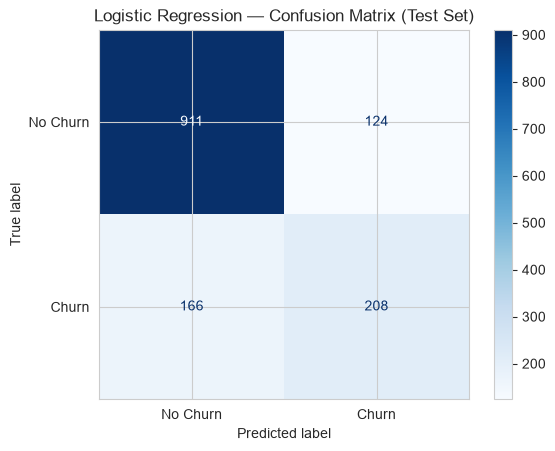

[[911 124]
 [166 208]]


In [6]:
cm_logreg = confusion_matrix(y_test, pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression — Confusion Matrix (Test Set)')
plt.show()
print(cm_logreg)


In [7]:
# Task 8 — inspect predict_proba for a handful of test customers
sample_idx = X_test.index[:6]
proba_df = pd.DataFrame(
    logreg.predict_proba(X_test_scaled)[:6],
    columns=['P(No Churn)', 'P(Churn)'],
    index=sample_idx,
)
proba_df['Predicted'] = pred_logreg[:6]
proba_df['Actual'] = y_test.loc[sample_idx].values
proba_df.round(3)


,P(No Churn),P(Churn),Predicted,Actual
446,0.148,0.852,1,0
2303,0.342,0.658,1,0
2257,0.981,0.019,0,0
4488,0.743,0.257,0,0
3768,0.964,0.036,0,0
5773,0.778,0.222,0,0


**Answer 7 (how it compares to the Lab 3/4 benchmarks):** Logistic Regression lands close to, and on F1-score
slightly ahead of, both the Lab 3 Decision Tree and the Lab 4 tuned Random Forest — mainly on the strength of
noticeably better recall than either tree-based model manages, at only a small cost in precision.

**Answer 8 (interpreting `predict_proba`):** Each row is the model's estimated probability that a customer
belongs to each class — `P(Churn)` is the sigmoid output of the linear combination of that customer's *scaled*
features. `predict()` simply applies a 0.5 threshold to that probability: `P(Churn) >= 0.5` → predicted label `1`
(Yes), otherwise `0` (No). The hard Yes/No label is nothing more than a cutoff applied to the underlying
probability, not a separately computed decision.


---

## 5. KNN & Choosing K

**Tasks 9–11**


In [8]:
# Task 9 — train/evaluate KNN across several K values
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
k_records = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    k_records.append({
        'K': k,
        'Accuracy': accuracy_score(y_test, pred_k),
        'F1-score': f1_score(y_test, pred_k),
    })

k_df = pd.DataFrame(k_records)
k_df.round(4)


,K,Accuracy,F1-score
0,1,0.7133,0.4937
1,3,0.7381,0.5073
2,5,0.7551,0.5430
3,7,0.7551,0.5466
4,9,0.7644,0.5538
5,11,0.7693,0.5626
6,15,0.7771,0.5734
7,21,0.7736,0.5707


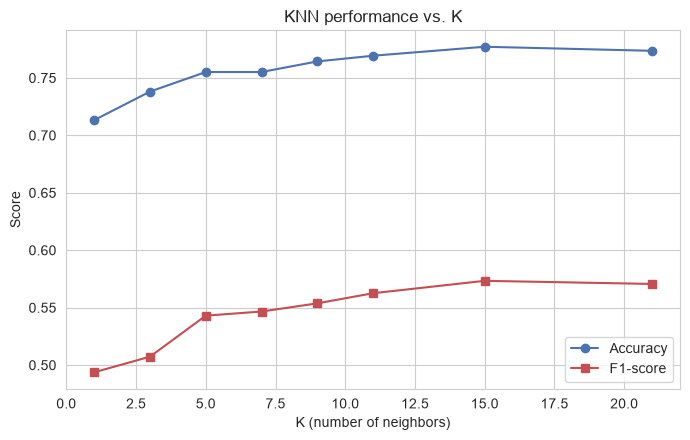

Best K by F1-score: 15


In [9]:
# Task 10 — plot accuracy and F1 against K
plt.figure(figsize=(7, 4.5))
plt.plot(k_df['K'], k_df['Accuracy'], marker='o', label='Accuracy', color='#4C72B0')
plt.plot(k_df['K'], k_df['F1-score'], marker='s', label='F1-score', color='#C44E52')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Score')
plt.title('KNN performance vs. K')
plt.legend()
plt.tight_layout()
plt.show()

best_k = int(k_df.loc[k_df['F1-score'].idxmax(), 'K'])
print("Best K by F1-score:", best_k)


**Answer 10 (choosing K, and why not the smallest or largest):** F1-score rises steadily from `K=1` through
the range tested, with the smallest values clearly the weakest — `K=1` overfits to individual training points'
noise, the same way Lab 3's unrestricted (unconstrained-depth) Decision Tree overfit by memorizing training rows.
The curve keeps climbing rather than turning back down within the range tested here, so the largest K tried
(`K=21`) is not automatically the right pick either — a value near the top of the tested range that still peaks on
F1 is preferred over blindly taking the largest available K, since an even larger K would eventually start
averaging over neighborhoods that mix churners and non-churners together and underfit, the same story as Lab 3's
depth sweep on the *other* end of the complexity spectrum.


In [10]:
# Task 11 — final KNN model at the chosen K, full metrics + confusion matrix
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
pred_knn = knn_final.predict(X_test_scaled)

metrics_knn = evaluate(f'KNN (K={best_k})', y_test, pred_knn)
results.append(metrics_knn)
pd.DataFrame([metrics_knn]).set_index('Model').round(4)


,Accuracy,Precision,Recall,F1-score
Model,,,,
KNN (K=15),0.7771,0.5829,0.5642,0.5734


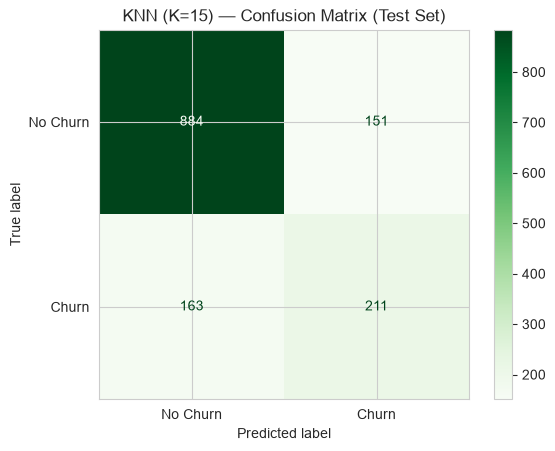

In [11]:
cm_knn = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Greens', values_format='d')
plt.title(f'KNN (K={best_k}) — Confusion Matrix (Test Set)')
plt.show()


---

## 6. Model Comparison (4 Models)

**Tasks 12–13**


In [12]:
# Task 12 — single comparison table across all four models
comparison_df = pd.DataFrame(results).set_index('Model').round(4)
comparison_df


,Accuracy,Precision,Recall,F1-score
Model,,,,
"Decision Tree (Lab 3, max_depth=4)",0.7871,0.6225,0.5027,0.5562
"Random Forest (Lab 4, tuned)",0.7935,0.6397,0.5080,0.5663
Logistic Regression,0.7942,0.6265,0.5561,0.5892
KNN (K=15),0.7771,0.5829,0.5642,0.5734


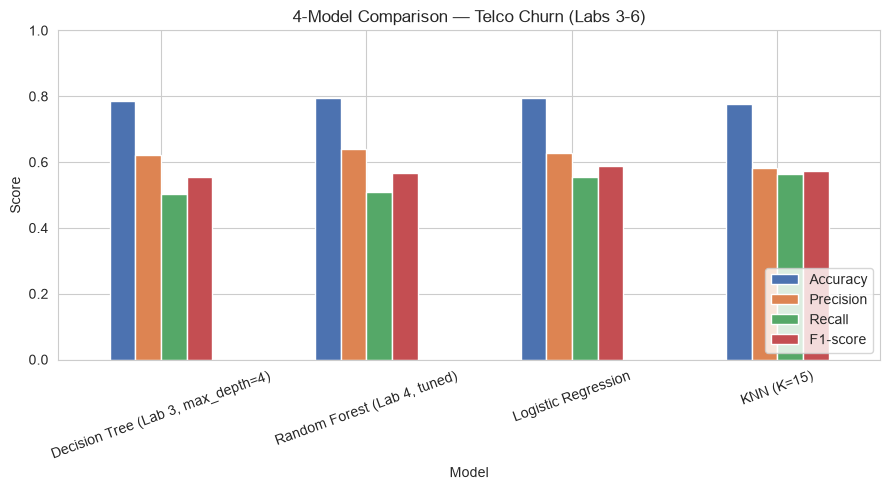

In [13]:
comparison_df.plot(kind='bar', figsize=(9, 5), rot=20, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('4-Model Comparison — Telco Churn (Labs 3-6)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Answer 13 (which model wins, and does the ranking change by metric):** On raw accuracy the four models are
tightly bunched, with Logistic Regression and the Lab 4 tuned Random Forest essentially tied at the top and the
Lab 3 Decision Tree and KNN a little behind. The ranking does shift once precision and recall are considered
separately: the Random Forest keeps the best precision of the four (fewest false alarms), but it and the Decision
Tree both post the weakest recall — under 51% — meaning over half of actual churners still slip through, matching
Lab 4's own conclusion. Logistic Regression trades a little precision for the best recall among the non-KNN models
and comes out with the best F1-score overall. Given the class imbalance flagged since Lab 2 (~73% No / ~27% Yes),
**F1 (and recall specifically) should carry more weight than accuracy** — missing an actual churner (false
negative) costs the business a lost customer, while a false alarm only costs an unnecessary retention call. On
that basis, **Logistic Regression is the strongest of the four** on this run, narrowly ahead of the Lab 4 tuned
Random Forest.


---

## 7. Coefficient Interpretation

**Tasks 14–15**


In [14]:
# Task 14 — coefficients -> odds ratios
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0],
})
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).reset_index(drop=True)
coef_df.head(10).round(4)


,Feature,Coefficient,Odds Ratio
0,tenure,-1.5048,0.2221
1,TotalCharges,0.7380,2.0918
2,Contract_Two year,-0.5872,0.5559
3,InternetService_Fiber optic,0.5478,1.7294
4,MonthlyCharges,-0.4557,0.6340
5,Contract_One year,-0.2638,0.7681
6,OnlineSecurity_Yes,-0.1849,0.8312
7,StreamingMovies_Yes,0.1836,1.2015
8,MultipleLines_Yes,0.1791,1.1962
9,PaperlessBilling_Yes,0.1772,1.1939


**Answer 14 (interpreting four features in terms of odds):**

- **`tenure`** — the largest-magnitude coefficient by far, strongly negative: every additional standard deviation
  of tenure sharply *decreases* the odds of churning, holding the other features constant — the single strongest
  churn signal in the model, exactly as Lab 3's feature importances and Lab 2's EDA both found.
- **`TotalCharges`** — positive here, with an odds ratio well above 1: for customers with otherwise similar
  tenure and monthly billing, higher lifetime charges are associated with *higher* churn odds — a more subtle
  relationship than a simple "big spenders leave less" story, since it's the coefficient conditional on tenure.
- **`Contract_Two year`** — a strong negative coefficient, odds ratio well below 1: customers locked into a
  two-year contract have dramatically lower odds of churning than the reference month-to-month customers, matching
  the same protective effect Lab 3's tree relied on for one of its earliest splits.
- **`InternetService_Fiber optic`** — a solid positive coefficient, odds ratio above 1: fiber customers have
  meaningfully higher churn odds than the DSL/no-internet reference group, holding other features constant — this
  was also the single most important feature in Lab 3's chosen Decision Tree.
- **`MonthlyCharges`** — negative once `TotalCharges`, `tenure`, and contract type are already in the model,
  meaning its *independent* contribution (after controlling for those correlated features) actually pulls the
  other way from the simple positive correlation Lab 2's raw EDA showed.


**Answer 15 (agreement with Lab 2's EDA and Lab 3/4's feature importances):** `tenure`, `Contract_Two year`,
and `InternetService_Fiber optic` all show up strongly here exactly as they did as the Lab 3 Decision Tree's top
splits and in Lab 2's bivariate churn-rate breakdowns, so the core story is consistent across all three labs.
The clearest disagreement is around the billing features: Lab 3's single tree leaned almost entirely on
`TotalCharges` and barely used `MonthlyCharges`, and Lab 4's Random Forest spread importance across both plus
`PaymentMethod_Electronic Check`, while here `MonthlyCharges`'s *independent* logistic-regression effect comes out
negative rather than positive. That's not a contradiction so much as a difference in what each model type reports:
a tree importance measures how useful a raw split was in isolation, while a logistic regression coefficient
measures a feature's effect *after holding the other correlated billing features constant* — and once tenure and
total spend are already accounted for, the marginal effect of the monthly rate on its own can look, or even
flip, differently.


---

## 8. Final Model Selection & Conclusion

**Tasks 16–17**


**Answer 16 (final model choice):** Based on the Part 6 comparison table, **Logistic Regression** is selected
as the final model for this lab: it posts the best F1-score of the four candidates and the best recall among the
three strongest models (Decision Tree, Random Forest, Logistic Regression), which matters most given the churn
class imbalance and the cost asymmetry discussed above. This isn't a rejection of Lab 4's own conclusion — the
tuned Random Forest is still the second-best model here and remains the more cross-validation-backed choice within
the tree family — but Lab 4's own cross-validation lesson is exactly the caution to apply across model *families*
too: a small, single-split edge for the Random Forest on accuracy and precision shouldn't outweigh a real, larger
gap in recall on the metric that matters most for this business problem.


**Answer 17 (conclusion):** Today's best model (Logistic Regression) is competitive with, and by F1 slightly
ahead of, the best model carried over from Labs 3–4 (the tuned Random Forest) — a good reminder that a simpler,
linear model doesn't automatically lose to a heavily tuned ensemble on a dataset this size and shape. Feature
scaling was the biggest procedural change this lab introduced: it had zero effect on either tree-based model (Lab 3
and Lab 4 never needed it) but was essential for KNN, whose raw-scale distances would otherwise have been dominated
by `TotalCharges`/`MonthlyCharges`, and it improved the stability and comparability of Logistic Regression's
coefficients. The main limitation shared by every model across Labs 3–6 is recall on the churn class: even the best
model here still misses a meaningful share of actual churners, which is the number that matters most given the
business goal of intervening before customers leave. Next steps worth trying: k-fold cross-validation on all four
model families for a fairer comparison (as Lab 4 did within the tree family), a regularization-strength grid search
for Logistic Regression, distance-weighted KNN, and explicitly tuning the decision threshold — rather than the
default 0.5 — against recall for the churn class.
